# Lorenz96 metric curves

This notebook mirrors `L63_metric_curves.ipynb` for Lorenz96 and renders only Energy Score (ES) and Rank-Histogram Variance (RHVar). It reads ML results from `save/lorenz96_results` and classic benchmark results from `save/benchmark_lorenz96`.


In [1]:
# Path bootstrap: if running from ./test_notebooks, move to project root
from pathlib import Path
import os

cwd = Path.cwd().resolve()
if cwd.name == 'test_notebooks':
    os.chdir(cwd.parent)
    cwd = Path.cwd().resolve()

print('Current working directory:', cwd)


Current working directory: /home/bhchen/LearnKalmanGain


In [2]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# torch is required to read output_records_*.pt
import torch


In [3]:
# Ensure cwd is project root (where ./save exists)
cwd = Path.cwd().resolve()
if not (cwd / 'save').exists() and (cwd.parent / 'save').exists():
    os.chdir(cwd.parent)

PROJECT_ROOT = Path.cwd().resolve()
SAVE_DIR = PROJECT_ROOT / 'save'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('SAVE_DIR exists =', SAVE_DIR.exists())


PROJECT_ROOT = /home/bhchen/LearnKalmanGain
SAVE_DIR exists = True


In [4]:
# =========================
# User config for Lorenz96 metric curves
# =========================
DATASET = 'lorenz96'
OBS_FN = 'identity'  # default obs_fn for diagnostics printed below
ALL_OBS_FNS = ['identity', 'square', 'arctan']
METRIC_OBS_FN_LIST = ['identity', 'square', 'arctan']
OBS_FN_SIGMA_Y = {
    'identity': 1.0,
    'square': 6.69,
    'arctan': 0.27,
}
SIGMA_Y = OBS_FN_SIGMA_Y[OBS_FN]

AXIS_LABEL_FONTSIZE = 22
TICK_FONTSIZE = 18

VAL_N_LIST = [5, 10, 15, 20, 40, 60, 100]
RESULTS_ROOT = SAVE_DIR / f'{DATASET}_results'
BENCHMARK_ROOT_CANDIDATES = [
    PROJECT_ROOT / f'benchmark_{DATASET}',
    SAVE_DIR / f'benchmark_{DATASET}',
]
BENCHMARK_ROOT = next((p for p in BENCHMARK_ROOT_CANDIDATES if p.exists()), BENCHMARK_ROOT_CANDIDATES[-1])
FIG_SAVE_DIR = SAVE_DIR / 'figures' / f'{DATASET}_metric_curves_notebook'
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('RESULTS_ROOT =', RESULTS_ROOT)
print('BENCHMARK_ROOT =', BENCHMARK_ROOT)
print('FIG_SAVE_DIR =', FIG_SAVE_DIR)
print('METRIC_OBS_FN_LIST =', METRIC_OBS_FN_LIST)


RESULTS_ROOT = /home/bhchen/LearnKalmanGain/save/lorenz96_results
BENCHMARK_ROOT = /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96
FIG_SAVE_DIR = /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook
METRIC_OBS_FN_LIST = ['identity', 'square', 'arctan']


In [5]:
def safe_torch_load(path):
    path = str(path)
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')


def save_figure_png_pdf(fig, png_path, **savefig_kwargs):
    png_path = Path(png_path)
    pdf_path = png_path.with_suffix('.pdf')
    fig.savefig(png_path, **savefig_kwargs)
    fig.savefig(pdf_path, **savefig_kwargs)
    print('Saved:', png_path)
    print('Saved:', pdf_path)
    return png_path, pdf_path


def _has_any_output_records(folder):
    return any(folder.glob('output_records_*.pt'))


BENCHMARK_METHOD_ORDER = {
    'ESRF': 0,
    'EnKF': 1,
    'iEnKS-PertObs': 2,
    'iEnKS-Sqrt': 3,
}
BENCHMARK_METHOD_LABELS = {
    'iEnKS-PertObs': 'IEnKF',
}


def discover_benchmark_dirs(obs_fn: str):
    sigma_y = OBS_FN_SIGMA_Y[obs_fn]
    benchmark_glob = str(BENCHMARK_ROOT / f'benchmark_{DATASET}_{sigma_y}_*')
    dirs = [Path(p) for p in glob.glob(benchmark_glob) if Path(p).is_dir()]
    out = []
    prefix = f'benchmark_{DATASET}_{sigma_y}_'
    for d in dirs:
        name = d.name
        method = name.replace(prefix, '') if name.startswith(prefix) else name
        if method not in BENCHMARK_METHOD_ORDER:
            continue
        out.append({
            'label': BENCHMARK_METHOD_LABELS.get(method, method),
            'dir': d,
            'kind': 'classic',
            'method': method,
            'obs_fn': obs_fn,
        })

    out.sort(key=lambda spec: (BENCHMARK_METHOD_ORDER[spec['method']], spec['dir'].name))
    return out


TRAINING_MODEL_ORDER = {'ES': 0, 'NL2': 1}
TRAINING_LOSS_ORDER = {'EtE-LRes': 0, 'CorrTerms': 1}


def format_training_label(model: str, loss: str) -> str:
    if loss == 'EtE-LRes':
        return f'EtE + {model}'
    return f'{loss}+{model}'


def parse_training_folder(folder_name: str):
    m = re.search(r'_(?P<model>es|nl2)_joint_(?P<loss>[^_/]+)None_(?P<obs_fn>.+)$', folder_name)
    if not m:
        return None
    return {
        'model': m.group('model').upper(),
        'loss': m.group('loss').replace('None', '').strip('_'),
        'obs_fn': m.group('obs_fn'),
    }


def discover_training_dirs(obs_fn: str, root: Path = RESULTS_ROOT):
    if (not root.exists()) or (not root.is_dir()):
        return []

    specs = []
    for d in sorted(root.iterdir()):
        if (not d.is_dir()) or (not _has_any_output_records(d)):
            continue
        meta = parse_training_folder(d.name)
        if meta is None or meta['obs_fn'] != obs_fn:
            continue
        if meta['model'] not in TRAINING_MODEL_ORDER or meta['loss'] not in TRAINING_LOSS_ORDER:
            continue
        specs.append({
            'label': format_training_label(meta['model'], meta['loss']),
            'dir': d,
            'kind': 'train',
            'model': meta['model'],
            'loss': meta['loss'],
            'obs_fn': obs_fn,
        })

    specs.sort(
        key=lambda spec: (
            TRAINING_MODEL_ORDER[spec['model']],
            TRAINING_LOSS_ORDER[spec['loss']],
            spec['dir'].name,
        )
    )
    return specs


def build_obs_fn_bundle(obs_fn: str):
    return {
        'obs_fn': obs_fn,
        'sigma_y': OBS_FN_SIGMA_Y[obs_fn],
        'benchmark_specs': discover_benchmark_dirs(obs_fn),
        'training_specs': discover_training_dirs(obs_fn, RESULTS_ROOT),
        'training_root': RESULTS_ROOT,
        'benchmark_root': BENCHMARK_ROOT,
    }


def metric_from_record(record_dict, key_candidates):
    candidate_bases = [
        record_dict.get('test_results', {}),
        record_dict.get('nn', {}),
        record_dict,
    ]
    for base in candidate_bases:
        if not isinstance(base, dict):
            continue
        for k in key_candidates:
            if k in base and base[k] is not None:
                try:
                    return float(base[k])
                except Exception:
                    continue
    return np.nan


def collect_metric_table(method_spec, n_values, metric_key_candidates):
    xs, ys = [], []
    for N in n_values:
        rec_path = method_spec['dir'] / f'output_records_{N}.pt'
        if rec_path.exists():
            record = safe_torch_load(rec_path)
            val = metric_from_record(record, metric_key_candidates)
        else:
            val = np.nan
        xs.append(N)
        ys.append(val)
    return np.array(xs, dtype=float), np.array(ys, dtype=float)


In [6]:
obs_fn_bundles = {obs_fn: build_obs_fn_bundle(obs_fn) for obs_fn in ALL_OBS_FNS}

metric_method_specs = {
    obs_fn: obs_fn_bundles[obs_fn]['benchmark_specs'] + obs_fn_bundles[obs_fn]['training_specs']
    for obs_fn in METRIC_OBS_FN_LIST
}

BASELINE_METHOD_LABEL = 'EtE + ES'

for obs_fn in ALL_OBS_FNS:
    bundle = obs_fn_bundles[obs_fn]
    print('==================================================')
    print(f'obs_fn={obs_fn} | sigma_y={bundle["sigma_y"]}')
    print('Benchmark root:', bundle['benchmark_root'])
    print('Benchmark dirs found:', len(bundle['benchmark_specs']))
    for s in bundle['benchmark_specs']:
        print('  -', s['label'], '|', s['dir'])
    print('Training root:', bundle['training_root'])
    print('Training dirs found:', len(bundle['training_specs']))
    for s in bundle['training_specs']:
        print('  -', s['label'], '|', s['dir'])


obs_fn=identity | sigma_y=1.0
Benchmark root: /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96
Benchmark dirs found: 3
  - ESRF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_ESRF
  - EnKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_EnKF
  - IEnKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_iEnKS-PertObs
Training root: /home/bhchen/LearnKalmanGain/save/lorenz96_results
Training dirs found: 4
  - EtE + ES | /home/bhchen/LearnKalmanGain/save/lorenz96_results/2026-02-28_14-41lorenz96_1.0_10_60_8192_es_joint_EtE-LResNone_identity
  - CorrTerms+ES | /home/bhchen/LearnKalmanGain/save/lorenz96_results/2026-02-28_14-42lorenz96_1.0_10_60_8192_es_joint_CorrTermsNone_identity
  - EtE + NL2 | /home/bhchen/LearnKalmanGain/save/lorenz96_results/2026-02-28_14-41lorenz96_1.0_10_60_8192_nl2_joint_EtE-LResNone_identity
  - CorrTerms+NL2 | /home/bhchen/LearnKalmanGain/save/lorenz96_results/2026-02-28_14

## Metric definitions

Only Energy Score (ES) and rank-histogram variance (RHVar) are plotted. Relative improvement is computed for ES against `BASELINE_METHOD_LABEL`, matching the L63 notebook convention: `(method - baseline) / method`, so positive values mean the baseline has a lower ES than that method.


In [7]:
METRIC_SPECS = [
    ('ES', ['mean_es1'], True),
    ('RHVar', ['rank_freq_var'], False),
]

METRIC_FIG_WIDTH = 5.4
METRIC_FIG_HEIGHT = 4.4
METRIC_COMBINED_COLS = 2
METRIC_EQUAL_SPACING_WIDTH_THRESHOLD = 7.5


def _slug(s):
    return re.sub(r'[^A-Za-z0-9]+', '_', str(s)).strip('_')


def use_equal_spaced_metric_x(fig_width):
    return fig_width < METRIC_EQUAL_SPACING_WIDTH_THRESHOLD


def get_metric_plot_x(x_values, fig_width):
    x_values = np.asarray(x_values, dtype=float)
    if use_equal_spaced_metric_x(fig_width):
        return np.arange(len(x_values), dtype=float)
    return x_values


def apply_metric_xaxis_ticks(ax, fig_width):
    if use_equal_spaced_metric_x(fig_width):
        ax.set_xticks(np.arange(len(VAL_N_LIST), dtype=float))
        ax.set_xticklabels([str(v) for v in VAL_N_LIST])
    else:
        ax.set_xticks(VAL_N_LIST)


def _compute_relative_improvement(series, baseline_series):
    series = np.asarray(series, dtype=float)
    baseline_series = np.asarray(baseline_series, dtype=float)
    out = np.full(series.shape, np.nan, dtype=float)
    valid = np.isfinite(series) & np.isfinite(baseline_series) & (np.abs(series) > 1e-12)
    out[valid] = (series[valid] - baseline_series[valid]) / series[valid]
    return out


def _format_metric_axis(ax, ylabel):
    ax.set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONTSIZE)
    apply_metric_xaxis_ticks(ax, METRIC_FIG_WIDTH)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax.grid(alpha=0.3)


def plot_metric_vs_N(metric_name, metric_keys, obs_fn=None, save=True, show_relative=False):
    obs_fn = obs_fn or OBS_FN
    method_specs = metric_method_specs[obs_fn]

    metric_curves = {}
    for spec in method_specs:
        x, y = collect_metric_table(spec, VAL_N_LIST, metric_keys)
        metric_curves[spec['label']] = {'x': x, 'y': y}

    baseline_curve = metric_curves.get(BASELINE_METHOD_LABEL)
    baseline_y = baseline_curve['y'] if baseline_curve is not None else np.full(len(VAL_N_LIST), np.nan, dtype=float)
    if show_relative and baseline_curve is None:
        print(f'[warn] baseline method missing for obs_fn={obs_fn}: {BASELINE_METHOD_LABEL}')

    if show_relative:
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(METRIC_FIG_WIDTH * METRIC_COMBINED_COLS, METRIC_FIG_HEIGHT),
            sharex=False,
        )
        ax_metric, ax_rel = axes
    else:
        fig, ax_metric = plt.subplots(1, 1, figsize=(METRIC_FIG_WIDTH, METRIC_FIG_HEIGHT), sharex=False)
        ax_rel = None

    for spec in method_specs:
        label = spec['label']
        x = metric_curves[label]['x']
        y = metric_curves[label]['y']
        plot_x = get_metric_plot_x(x, METRIC_FIG_WIDTH)
        valid = np.isfinite(y)
        if np.any(valid):
            (line,) = ax_metric.plot(plot_x[valid], y[valid], marker='o', linewidth=1.8, label=label)
        else:
            print(f'[warn] no valid points for metric={metric_name}, obs_fn={obs_fn}, method={label}')
            (line,) = ax_metric.plot([], [], marker='o', linewidth=1.8, label=label)

        if show_relative:
            rel = _compute_relative_improvement(y, baseline_y)
            rel_valid = np.isfinite(rel)
            if np.any(rel_valid):
                ax_rel.plot(plot_x[rel_valid], rel[rel_valid], marker='o', linewidth=1.8, color=line.get_color())
            else:
                print(f'[warn] no valid rel-improvement points for metric={metric_name}, obs_fn={obs_fn}, method={label}')
                ax_rel.plot([], [], marker='o', linewidth=1.8, color=line.get_color())

    _format_metric_axis(ax_metric, metric_name)
    ax_metric.set_title(obs_fn, fontsize=AXIS_LABEL_FONTSIZE)

    if show_relative:
        _format_metric_axis(ax_rel, 'Relative improvement')
        ax_rel.axhline(0, color='0.5', linewidth=1.0, linestyle='--')
        ax_rel.set_title(f'{obs_fn}: {BASELINE_METHOD_LABEL}', fontsize=AXIS_LABEL_FONTSIZE)

    handles, labels = ax_metric.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.84, 1])

    if save:
        out = FIG_SAVE_DIR / f'L96_{_slug(obs_fn)}_{_slug(metric_name)}_vs_N.png'
        save_figure_png_pdf(fig, out, dpi=180, bbox_inches='tight')
    plt.show()
    return fig, metric_curves


[warn] no valid points for metric=ES, obs_fn=identity, method=IEnKF
[warn] no valid rel-improvement points for metric=ES, obs_fn=identity, method=IEnKF
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_identity_ES_vs_N.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_identity_ES_vs_N.pdf


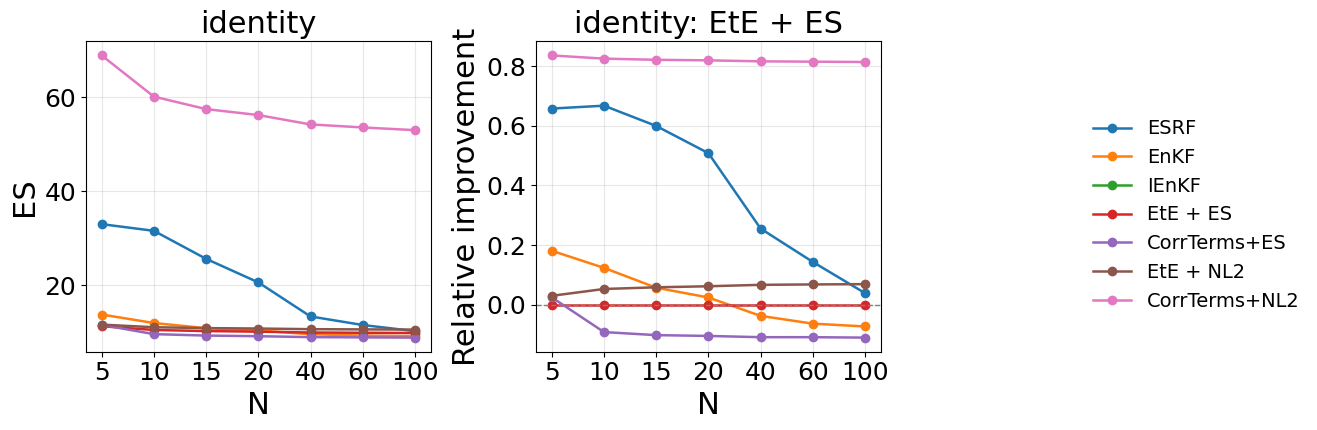

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_identity_RHVar_vs_N.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_identity_RHVar_vs_N.pdf


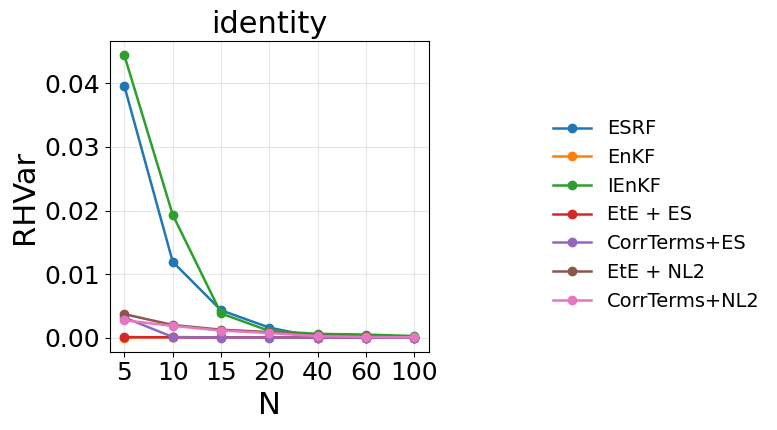

[warn] no valid points for metric=ES, obs_fn=square, method=IEnKF
[warn] no valid rel-improvement points for metric=ES, obs_fn=square, method=IEnKF
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_square_ES_vs_N.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_square_ES_vs_N.pdf


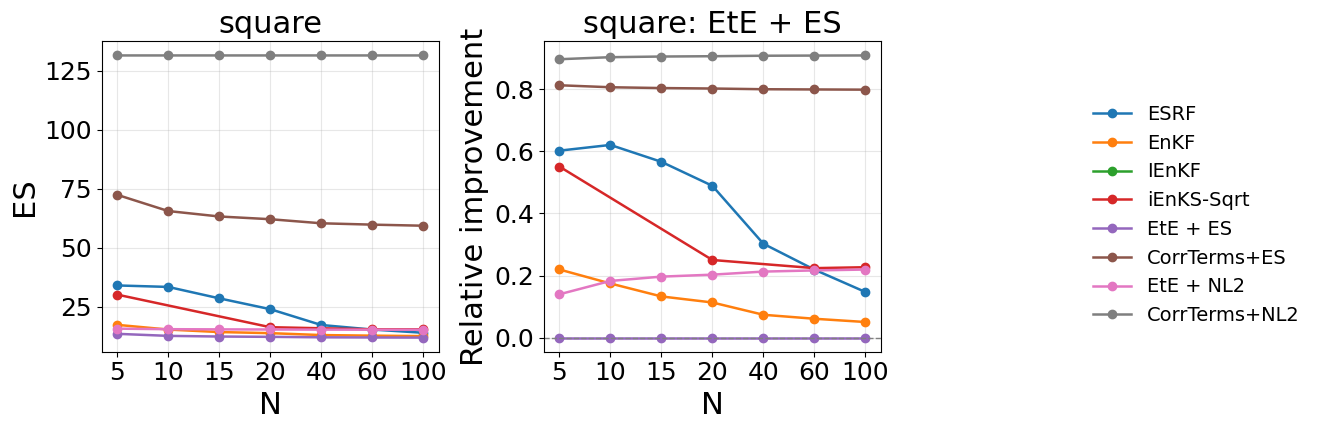

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_square_RHVar_vs_N.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_square_RHVar_vs_N.pdf


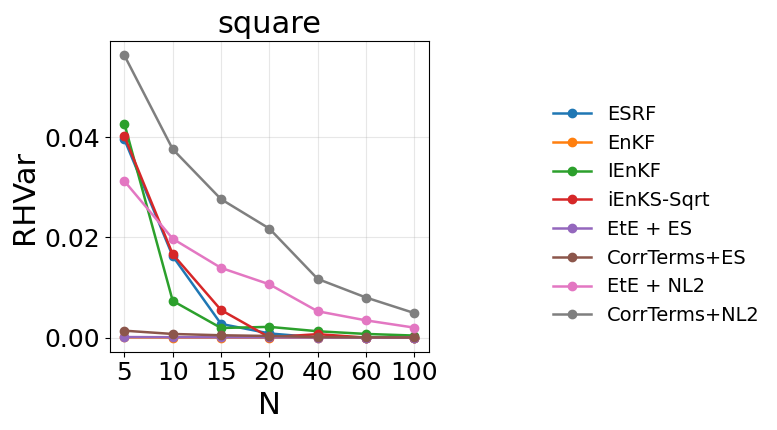

[warn] no valid points for metric=ES, obs_fn=arctan, method=IEnKF
[warn] no valid rel-improvement points for metric=ES, obs_fn=arctan, method=IEnKF
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_arctan_ES_vs_N.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_arctan_ES_vs_N.pdf


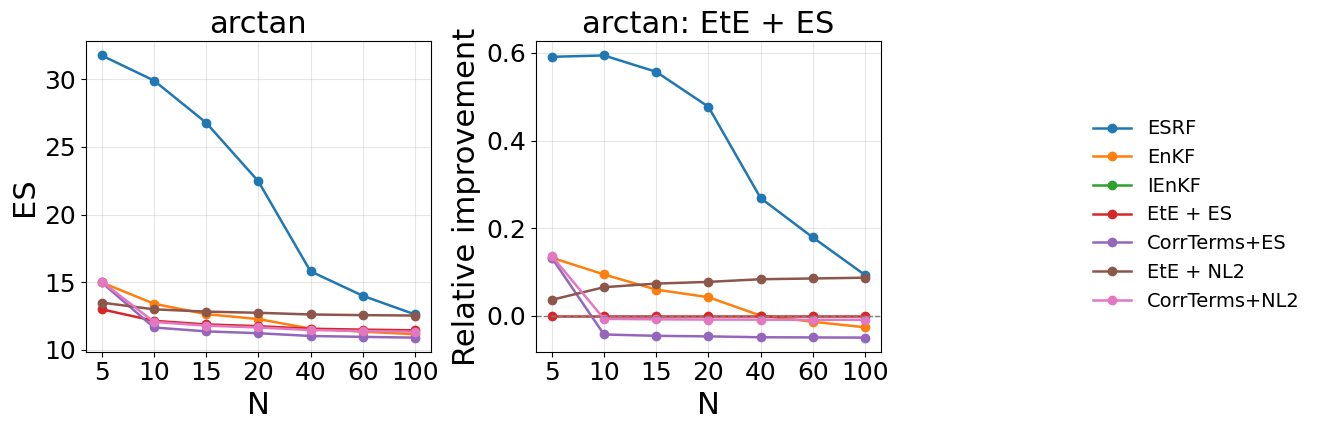

Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_arctan_RHVar_vs_N.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_arctan_RHVar_vs_N.pdf


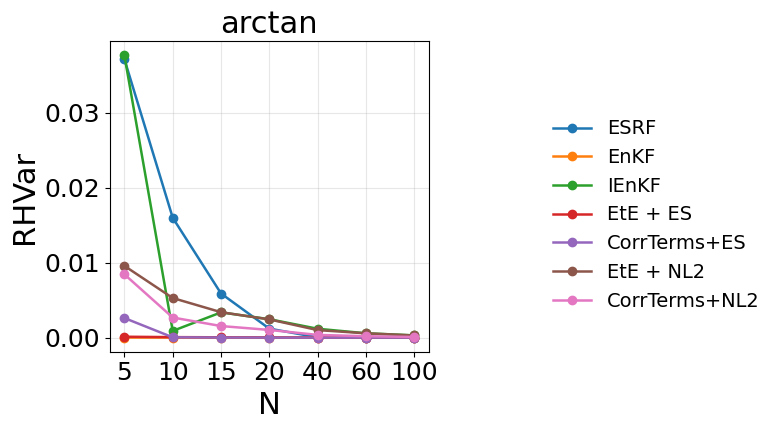

In [8]:
# Save individual metric figures for each observation function.
individual_metric_curves = {}
for obs_fn in METRIC_OBS_FN_LIST:
    for metric_name, metric_keys, show_relative in METRIC_SPECS:
        fig, curves = plot_metric_vs_N(
            metric_name,
            metric_keys,
            obs_fn=obs_fn,
            save=True,
            show_relative=show_relative,
        )
        individual_metric_curves[(obs_fn, metric_name)] = curves
        plt.close(fig)


## Combined 3x3 figure

Columns are `identity`, `square`, and `arctan`. Rows are ES, ES relative improvement, and RHVar.


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_combined_ES_RHVar_3x3.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_combined_ES_RHVar_3x3.pdf


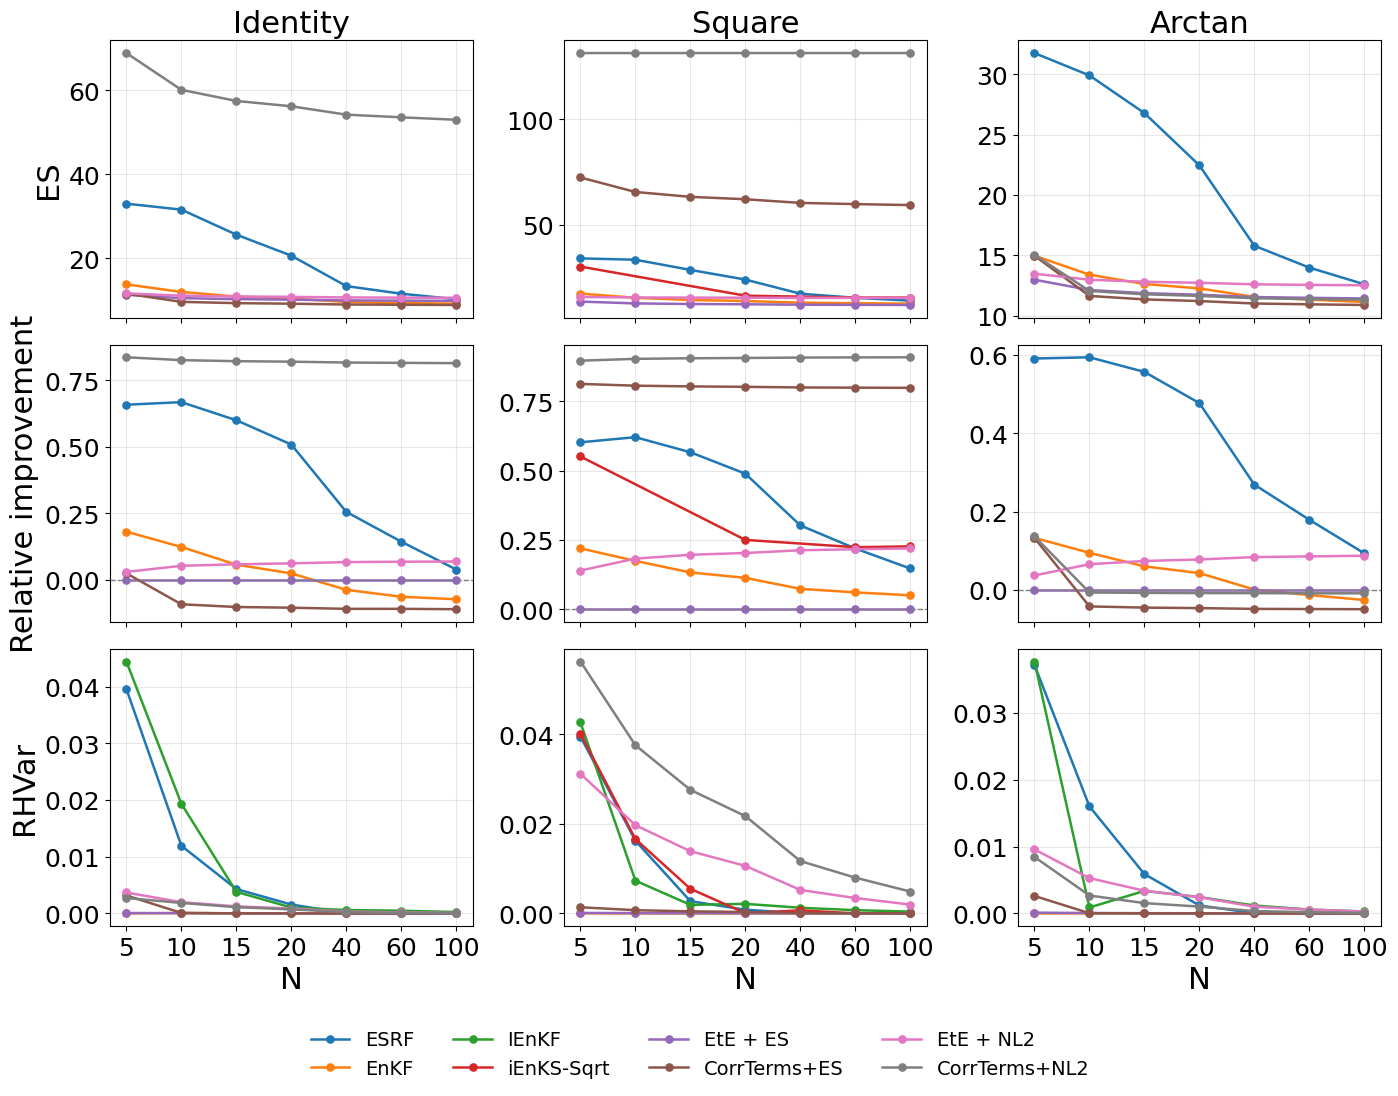

In [9]:
# =========================
# Combined multi-observation 3x3 figure
# =========================
COMBINED_OBS_FN_LIST = ['identity', 'square', 'arctan']
COMBINED_OBS_FN_TITLES = {
    'identity': 'Identity',
    'square': 'Square',
    'arctan': 'Arctan',
}
COMBINED_PANEL_WIDTH = 4.7
COMBINED_PANEL_HEIGHT = 3.6
COMBINED_LINEWIDTH = 1.8
COMBINED_MARKERSIZE = 5.2
COMBINED_LEGEND_FONTSIZE = 14
COMBINED_METHOD_ORDER = {
    'ESRF': 0,
    'EnKF': 1,
    'IEnKF': 2,
    'iEnKS-Sqrt': 3,
    'EtE + ES': 4,
    'CorrTerms+ES': 5,
    'EtE + NL2': 6,
    'CorrTerms+NL2': 7,
}


def _combined_method_specs(obs_fn):
    return list(metric_method_specs[obs_fn])


def _combined_method_labels():
    labels = []
    for obs_fn in COMBINED_OBS_FN_LIST:
        for spec in _combined_method_specs(obs_fn):
            label = spec['label']
            if label not in labels:
                labels.append(label)
    return sorted(labels, key=lambda label: (COMBINED_METHOD_ORDER.get(label, 999), label))


COMBINED_METHOD_LABELS = _combined_method_labels()
COMBINED_COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
COMBINED_METHOD_COLORS = {
    label: COMBINED_COLOR_CYCLE[i % len(COMBINED_COLOR_CYCLE)]
    for i, label in enumerate(COMBINED_METHOD_LABELS)
}


def _combined_curves(obs_fn, metric_keys):
    curves = {}
    for spec in _combined_method_specs(obs_fn):
        label = spec['label']
        x, y = collect_metric_table(spec, VAL_N_LIST, metric_keys)
        curves[label] = {'x': x, 'y': y}
    return curves


def plot_l96_metric_3x3(out_stem='L96_combined_ES_RHVar_3x3'):
    fig, axes = plt.subplots(
        3,
        len(COMBINED_OBS_FN_LIST),
        figsize=(COMBINED_PANEL_WIDTH * len(COMBINED_OBS_FN_LIST), COMBINED_PANEL_HEIGHT * 3),
        sharex=True,
    )

    legend_handles = {}
    es_keys = ['mean_es1']
    rhvar_keys = ['rank_freq_var']

    for col, obs_fn in enumerate(COMBINED_OBS_FN_LIST):
        es_curves = _combined_curves(obs_fn, es_keys)
        rhvar_curves = _combined_curves(obs_fn, rhvar_keys)
        baseline_curve = es_curves.get(BASELINE_METHOD_LABEL)
        baseline_y = baseline_curve['y'] if baseline_curve is not None else np.full(len(VAL_N_LIST), np.nan, dtype=float)
        if baseline_curve is None:
            print(f'[warn] baseline method missing for obs_fn={obs_fn}: {BASELINE_METHOD_LABEL}')

        for label in COMBINED_METHOD_LABELS:
            color = COMBINED_METHOD_COLORS[label]

            if label in es_curves:
                curve = es_curves[label]
                plot_x = get_metric_plot_x(curve['x'], COMBINED_PANEL_WIDTH)
                y = curve['y']
                valid = np.isfinite(y)
                if np.any(valid):
                    (line,) = axes[0, col].plot(
                        plot_x[valid],
                        y[valid],
                        marker='o',
                        linewidth=COMBINED_LINEWIDTH,
                        markersize=COMBINED_MARKERSIZE,
                        color=color,
                        label=label,
                    )
                    legend_handles[label] = line

                rel = _compute_relative_improvement(y, baseline_y)
                rel_valid = np.isfinite(rel)
                if np.any(rel_valid):
                    axes[1, col].plot(
                        plot_x[rel_valid],
                        rel[rel_valid],
                        marker='o',
                        linewidth=COMBINED_LINEWIDTH,
                        markersize=COMBINED_MARKERSIZE,
                        color=color,
                    )

            if label in rhvar_curves:
                curve = rhvar_curves[label]
                plot_x = get_metric_plot_x(curve['x'], COMBINED_PANEL_WIDTH)
                y = curve['y']
                valid = np.isfinite(y)
                if np.any(valid):
                    (line,) = axes[2, col].plot(
                        plot_x[valid],
                        y[valid],
                        marker='o',
                        linewidth=COMBINED_LINEWIDTH,
                        markersize=COMBINED_MARKERSIZE,
                        color=color,
                        label=label,
                    )
                    legend_handles[label] = line

        axes[0, col].set_title(COMBINED_OBS_FN_TITLES.get(obs_fn, obs_fn), fontsize=AXIS_LABEL_FONTSIZE)
        axes[1, col].axhline(0, color='0.5', linewidth=1.0, linestyle='--')
        for row in range(3):
            apply_metric_xaxis_ticks(axes[row, col], COMBINED_PANEL_WIDTH)
            axes[row, col].tick_params(axis='both', labelsize=TICK_FONTSIZE)
            axes[row, col].grid(alpha=0.3)
        axes[2, col].set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)

    axes[0, 0].set_ylabel('ES', fontsize=AXIS_LABEL_FONTSIZE)
    axes[1, 0].set_ylabel('Relative improvement', fontsize=AXIS_LABEL_FONTSIZE)
    axes[2, 0].set_ylabel('RHVar', fontsize=AXIS_LABEL_FONTSIZE)

    handles = [legend_handles[label] for label in COMBINED_METHOD_LABELS if label in legend_handles]
    labels = [label for label in COMBINED_METHOD_LABELS if label in legend_handles]
    fig.legend(
        handles,
        labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.02),
        ncol=min(4, max(1, len(labels))),
        frameon=False,
        fontsize=COMBINED_LEGEND_FONTSIZE,
    )
    fig.tight_layout(rect=[0, 0.06, 1, 1], h_pad=1.0, w_pad=1.2)

    out = FIG_SAVE_DIR / f'{out_stem}.png'
    save_figure_png_pdf(fig, out, dpi=180, bbox_inches='tight')
    plt.show()
    return fig


fig = plot_l96_metric_3x3()
plt.close(fig)
